In [18]:
import pandas as pd

df = pd.read_csv("state_data.csv")
df.head()

,state,latitude,longitude,name
0,AK,63.588753,-154.493062,Alaska
1,AL,32.318231,-86.902298,Alabama
2,AR,35.201050,-91.831833,Arkansas
3,AZ,34.048928,-111.093731,Arizona
4,CA,36.778261,-119.417932,California


In [19]:
print(df.shape)
print(df.columns)

(52, 4)
Index(['state', 'latitude', 'longitude', 'name'], dtype='object')


In [20]:
df.head()
df.tail()

,state,latitude,longitude,name
47,VT,44.558803,-72.577841,Vermont
48,WA,47.751074,-120.740139,Washington
49,WI,43.784440,-88.787868,Wisconsin
50,WV,38.597626,-80.454903,West Virginia
51,WY,43.075968,-107.290284,Wyoming


**What do the columns represent?**  
The "state" column shows abbreviations, "latitude" and "longitude" show geographic coordinates, and "name" shows the full state name.

**What is the first state?**  
Alaska

**What is the last state?**  
Wyoming

**How many entries are there?**  
51

**Why are there more than 50 states?**  
Because the dataset includes Washington DC and possibly other territories.

In [21]:
median_lat = df["latitude"].median()
median_lon = df["longitude"].median()

print(median_lat, median_lon)

39.4355155 -89.093198


In [22]:
df["lat_distance"] = abs(df["latitude"] - median_lat)
df["lon_distance"] = abs(df["longitude"] - median_lon)

In [23]:
print(df.shape)

(52, 6)


In [24]:
closest_lat = df.loc[df["lat_distance"].idxmin()]
farthest_lat = df.loc[df["lat_distance"].idxmax()]

closest_lon = df.loc[df["lon_distance"].idxmin()]
farthest_lon = df.loc[df["lon_distance"].idxmax()]

In [25]:
print(f'Closest to median latitude: {closest_lat["name"]} ({closest_lat["lat_distance"]:.2f})')
print(f'Farthest from median latitude: {farthest_lat["name"]} ({farthest_lat["lat_distance"]:.2f})')

print(f'Closest to median longitude: {closest_lon["name"]} ({closest_lon["lon_distance"]:.2f})')
print(f'Farthest from median longitude: {farthest_lon["name"]} ({farthest_lon["lon_distance"]:.2f})')

Closest to median latitude: Colorado (0.11)
Farthest from median latitude: Alaska (24.15)
Closest to median longitude: Illinois (0.31)
Farthest from median longitude: Hawaii (66.57)


In [26]:
df.sample(5)

,state,latitude,longitude,name,lat_distance,lon_distance
19,MA,42.407211,-71.382437,Massachusetts,2.971695,17.710761
11,HI,19.898682,-155.665857,Hawaii,19.536834,66.572659
38,PA,41.203322,-77.194525,Pennsylvania,1.767806,11.898673
10,GA,32.157435,-82.907123,Georgia,7.278081,6.186075
25,MS,32.354668,-89.398528,Mississippi,7.080848,0.305330


**Pandas Function Used:** `df.sample()`

I found the `sample()` function in the pandas documentation.

This function returns a random sample of rows from the DataFrame. In this case, `df.sample(5)` returns 5 random rows from the dataset.

This is useful when working with large datasets because it allows you to quickly inspect a random subset of the data without having to scroll through the entire DataFrame. It can also help identify patterns, outliers, or verify that the data looks correct.

In [1]:
print("hello")

hello


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
penguins_clean = penguins.dropna(axis=1)
penguins_clean.head()

,species,island
0,Adelie,Torgersen
1,Adelie,Torgersen
2,Adelie,Torgersen
3,Adelie,Torgersen
4,Adelie,Torgersen


In [5]:
print(penguins_clean.shape)
print("Rows:", penguins_clean.shape[0])
print("Columns:", penguins_clean.shape[1])

(344, 2)
Rows: 344
Columns: 2


In [6]:
print(penguins_clean.head())
print(penguins_clean.tail())

  species     island
0  Adelie  Torgersen
1  Adelie  Torgersen
2  Adelie  Torgersen
3  Adelie  Torgersen
4  Adelie  Torgersen
    species  island
339  Gentoo  Biscoe
340  Gentoo  Biscoe
341  Gentoo  Biscoe
342  Gentoo  Biscoe
343  Gentoo  Biscoe


In [7]:
print(penguins_clean.columns)

Index(['species', 'island'], dtype='object')


**Column descriptions**
- `species`: the penguin species
- `island`: the island where the penguin was observed
- `bill_length_mm`: bill length in millimeters
- `bill_depth_mm`: bill depth in millimeters
- `flipper_length_mm`: flipper length in millimeters
- `body_mass_g`: body mass in grams
- `sex`: biological sex of the penguin

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
tips_clean = tips.dropna(axis=1)

In [10]:
print(tips_clean.shape)
print("Rows:", tips_clean.shape[0])
print("Columns:", tips_clean.shape[1])

print(tips_clean.head())
print(tips_clean.tail())
print(tips_clean.columns)

(244, 7)
Rows: 244
Columns: 7
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
     total_bill   tip     sex smoker   day    time  size
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2
Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


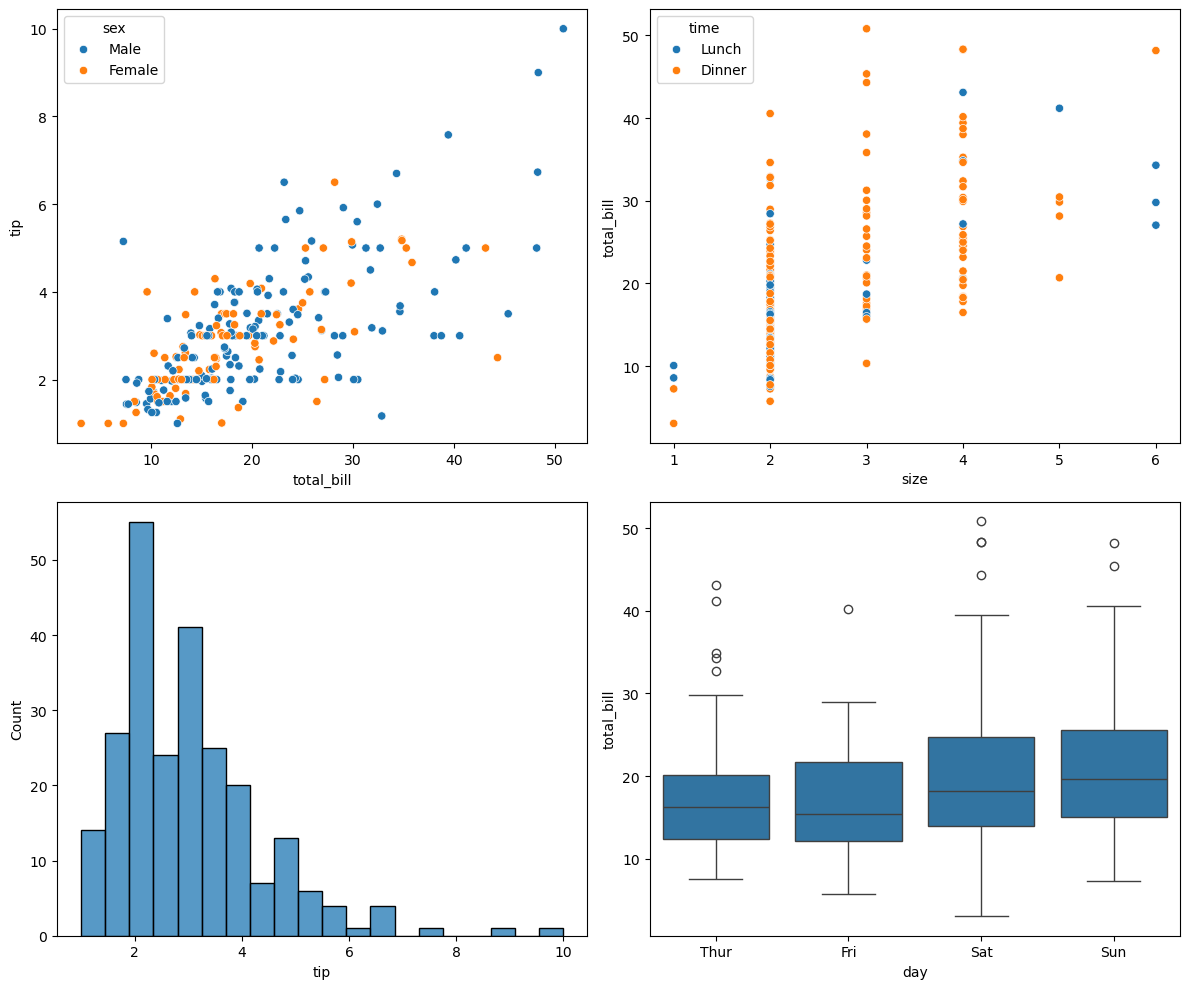

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(
    data=tips_clean,
    x="total_bill",
    y="tip",
    hue="sex",
    ax=axes[0, 0]
)

sns.scatterplot(
    data=tips_clean,
    x="size",
    y="total_bill",
    hue="time",
    ax=axes[0, 1]
)

sns.histplot(
    data=tips_clean,
    x="tip",
    bins=20,
    ax=axes[1, 0]
)

sns.boxplot(
    data=tips_clean,
    x="day",
    y="total_bill",
    ax=axes[1, 1]
)

plt.tight_layout()
plt.show()

**Dataset shape:**  
The cleaned tips dataset has ___ rows and ___ columns.

**Column descriptions:**  
- `total_bill`: total bill amount in dollars  
- `tip`: tip amount in dollars  
- `sex`: sex of the server/customer category in the dataset  
- `smoker`: whether the party included smokers  
- `day`: day of the week  
- `time`: lunch or dinner  
- `size`: party size  

**Subplot explanations**

**Top left: Tip vs Total Bill**  
This scatterplot shows the relationship between the total bill and the tip amount, with points colored by sex. I chose these columns because tips usually increase as the bill increases. The plot shows a positive relationship between total bill and tip.

**Top right: Total Bill vs Party Size**  
This scatterplot compares party size and total bill, with points colored by time. I chose these columns to see whether bigger groups tend to spend more. The plot suggests that larger parties often have higher total bills.

**Bottom left: Distribution of Tips**  
This histogram shows how tip amounts are distributed in the dataset. I chose this column because it helps summarize tipping behavior. Most tips appear concentrated at lower to moderate values, with fewer very large tips.

**Bottom right: Total Bill by Day**  
This boxplot compares total bill amounts across different days. I chose it because boxplots are useful for comparing distributions across categories. The plot shows differences in spending patterns by day, including variation and possible outliers.